<a href="https://colab.research.google.com/github/CodeArtist-Muhammad-Tayyeb/Age-Calculator/blob/main/Week_03_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**WEEK 03 PROJECT**



##**Project Title: NLP Preprocessing &amp; Machine Learning**


---

>**Submitted by:** Muhammad Tayyeb

>**Submitted to:** Fatima Khalid (Lab Engr)

>**Institute:** Ghulam Ishaq Khan Institute (GIKI), Topi, Swabi, Pakistan

>**Bootcamp:** ML to LLM 2025

>**Date of Submission:** August 17, 2025

##**Objective:**

---



>Apply NLP cleaning, preprocessing techniques, and machine learning models to a publicly
available text dataset, comparing results on stemmed vs. lemmatized data.

#**Dataset overview**

##**Dataset: SMS Spam Collection Dataset**



**Source:** The dataset is widely used for NLP and ML tasks. It’s hosted on the UCI Machine Learning Repository and also available on GitHub.

**Task Type:** Binary text classification (spam vs ham).

**Size:** 5,574 SMS messages.

**Columns:**

label → indicates whether the message is:

"ham" → not spam (a normal SMS)

"spam" → unwanted promotional/advertisement message

text → the actual SMS message content.


##**Why this dataset is chosen for your project?**

Small and easy to process → good for classroom teaching.

Real-world application → spam filtering is a direct NLP use-case.

Balanced enough to see differences between models.

Already labeled → supervised ML is possible.

##**Learning Outcomes for Students**

Understand text preprocessing (cleaning SMS messages).

Compare stemming vs lemmatization in a real dataset.

Apply TF-IDF feature extraction.

Train ML classifiers (Logistic Regression, Naive Bayes).

Evaluate models on spam detection task.

##**We’ll go in the following flow:**

1. Import libraries

2. Load dataset

3. Preprocessing (cleaning)

4. Tokenization, stopwords, spelling correction

5. Stemming vs Lemmatization

6. Feature extraction (TF-IDF)

7. Train-test split

8. Machine learning models

9. Evaluation (accuracy, precision, recall, F1, confusion matrix)

10. Visualizations (word clouds + accuracy chart)

# Step 1: Import all the required libraries

We import pandas, numpy for dataset handling.

Matplotlib, seaborn, wordcloud for visualizations.

NLTK & TextBlob for text cleaning, stemming, lemmatization, and spelling correction.

Scikit-learn for feature extraction, ML models, and evaluation metrics.

Finally, we download some NLTK resources (stopwords, wordnet, punkt tokenizer).

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from textblob import TextBlob

# Machine Learning libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download necessary resources from NLTK
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Step 2: Load SMS Spam dataset from a public URL

We use the SMS Spam Collection Dataset (widely used in NLP).

It has two columns: label (ham/spam) and text (message).

We display the shape and first 5 rows to understand the data.

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep="\t", header=None, names=["label", "text"])

# Show dataset info
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5572, 2)


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Step 3: Define preprocessing functions

This function cleans raw text by removing noise like URLs, emails, numbers, and punctuation.

Converts everything to lowercase to make the text uniform.

In [3]:
import re
import string

stop_words = set(stopwords.words("english"))
ps = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Cleaning steps:
    1. Convert to lowercase
    2. Remove URLs
    3. Remove Emails
    4. Replace numbers
    5. Remove punctuation
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " url ", text)  # replace URLs
    text = re.sub(r"\S+@\S+", " email ", text)  # replace emails
    text = re.sub(r"\d+", " number ", text)  # replace numbers
    text = text.translate(str.maketrans("", "", string.punctuation))  # remove punctuation
    return text

# Step 4: Tokenize text and remove stopwords

We use word_tokenize from NLTK.

Remove common stopwords like “is, the, and”.

Remove very short words (hi, ok).

In [4]:
def tokenize_and_remove_stopwords(text):
    """
    1. Tokenize sentence into words
    2. Remove stopwords (like 'is', 'the', 'and')
    3. Remove very short words (length < 3)
    """
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    return tokens

# Example
# example = "This is an example email: test@gmail.com, visit http://example.com!"
# print("Cleaned Text:", clean_text(example))
# print("Tokens:", tokenize_and_remove_stopwords(clean_text(example)))

# Step 5: Apply spelling correction using TextBlob

TextBlob is used to fix common spelling errors.

Example: “mesage” → “message”.

This helps in better feature extraction.

In [5]:
def spelling_correction(tokens):
    """
    Correct spelling for each token using TextBlob.
    (Note: This is slow for large datasets, so use carefully.)
    """
    corrected = []
    for word in tokens:
        corrected.append(str(TextBlob(word).correct()))
    return corrected

# Example
# print("Corrected Tokens:", spelling_correction(["spamm", "mesage", "frre"]))

# Step 6: Apply stemming and lemmatization

Stemming: Cuts words to their root form → “running” → “run”, “messages” → “messag”.

Lemmatization: Smarter, uses grammar → “flies” → “fly”, “better” → “good”.

We’ll compare both methods.

In [6]:
def apply_stemming(tokens):
    return [ps.stem(word) for word in tokens]

def apply_lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# Example
# tokens = ["running", "flies", "better", "messages"]
# print("Stemmed:", apply_stemming(tokens))
# print("Lemmatized:", apply_lemmatization(tokens))

# Step 7: Full preprocessing pipeline

Runs cleaning → tokenization → spelling correction → stemming/lemmatization.

Produces two corpora: one with stemmed words and one with lemmatized words.

In [7]:
def preprocess_pipeline(df, method="stem"):
    corpus = []
    for text in df["text"]:
        text = clean_text(text)
        tokens = tokenize_and_remove_stopwords(text)
        tokens = spelling_correction(tokens)  # slow but educational
        if method == "stem":
            tokens = apply_stemming(tokens)
        else:
            tokens = apply_lemmatization(tokens)
        corpus.append(" ".join(tokens))
    return corpus

print("Running preprocessing with stemming...")
stemmed_corpus = preprocess_pipeline(df, method="stem")

print("Running preprocessing with lemmatization...")
lemmatized_corpus = preprocess_pipeline(df, method="lemma")

Running preprocessing with stemming...
Running preprocessing with lemmatization...


# Step 8: Feature extraction with TF-IDF

Converts text into numerical vectors using TF-IDF (Term Frequency-Inverse Document Frequency).

This helps ML models understand the importance of words.

Splits into training (80%) and testing (20%).

In [8]:
vectorizer = TfidfVectorizer()

X_stem = vectorizer.fit_transform(stemmed_corpus)
X_lemma = vectorizer.fit_transform(lemmatized_corpus)
y = df["label"].map({"ham": 0, "spam": 1})  # Encode labels

# Train-Test Split
X_train_stem, X_test_stem, y_train, y_test = train_test_split(X_stem, y, test_size=0.2, random_state=42)
X_train_lemma, X_test_lemma, _, _ = train_test_split(X_lemma, y, test_size=0.2, random_state=42)

print("Shape of TF-IDF features (stemmed):", X_stem.shape)
print("Shape of TF-IDF features (lemmatized):", X_lemma.shape)

Shape of TF-IDF features (stemmed): (5572, 4972)
Shape of TF-IDF features (lemmatized): (5572, 5713)


# Step 9: Train Logistic Regression and Naive Bayes

Trains Logistic Regression and Naive Bayes on both stemmed and lemmatized datasets.

Stores accuracy, precision, recall, and F1 results.

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB()
}

results = {}

for model_name, model in models.items():
    # Train on stemmed corpus
    model.fit(X_train_stem, y_train)
    y_pred_stem = model.predict(X_test_stem)

    # Train on lemmatized corpus
    model.fit(X_train_lemma, y_train)
    y_pred_lemma = model.predict(X_test_lemma)

    # Evaluate
    acc_stem = accuracy_score(y_test, y_pred_stem)
    acc_lemma = accuracy_score(y_test, y_pred_lemma)

    results[model_name] = {
        "Stemmed Accuracy": acc_stem,
        "Lemmatized Accuracy": acc_lemma,
        "Stemmed Report": classification_report(y_test, y_pred_stem, target_names=["Ham", "Spam"]),
        "Lemmatized Report": classification_report(y_test, y_pred_lemma, target_names=["Ham", "Spam"])
    }

# Step 10: Show results

Prints out detailed evaluation reports for each model on both preprocessing methods.

Helps compare stemming vs lemmatization.

In [10]:
for model, res in results.items():
    print("\n======", model, "======")
    print("Stemmed Accuracy:", res["Stemmed Accuracy"])
    print(res["Stemmed Report"])
    print("Lemmatized Accuracy:", res["Lemmatized Accuracy"])
    print(res["Lemmatized Report"])


====== Logistic Regression ======
Stemmed Accuracy: 0.967713004484305
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98       966
        Spam       0.93      0.82      0.87       149

    accuracy                           0.97      1115
   macro avg       0.95      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115

Lemmatized Accuracy: 0.9668161434977578
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98       966
        Spam       0.94      0.81      0.87       149

    accuracy                           0.97      1115
   macro avg       0.95      0.90      0.92      1115
weighted avg       0.97      0.97      0.97      1115


====== Naive Bayes ======
Stemmed Accuracy: 0.9668161434977578
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       0.98      0.77      0.86       149

    acc

# Step 11: Compare accuracy with bar chart

Bar chart compares accuracy scores for stemming vs lemmatization.

Word clouds visualize the most frequent words in both versions of the dataset.

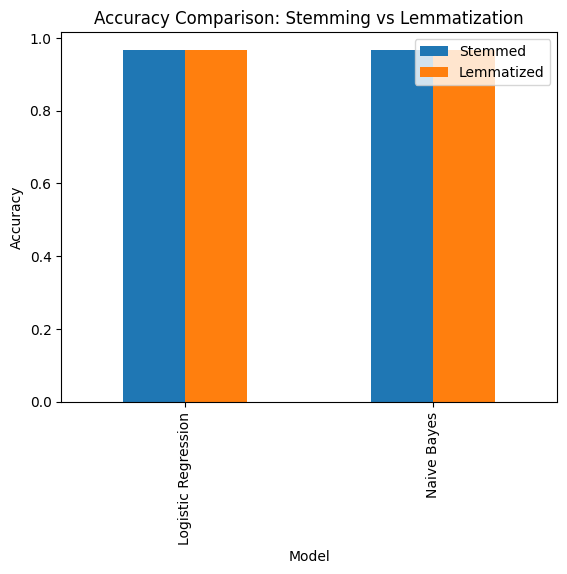

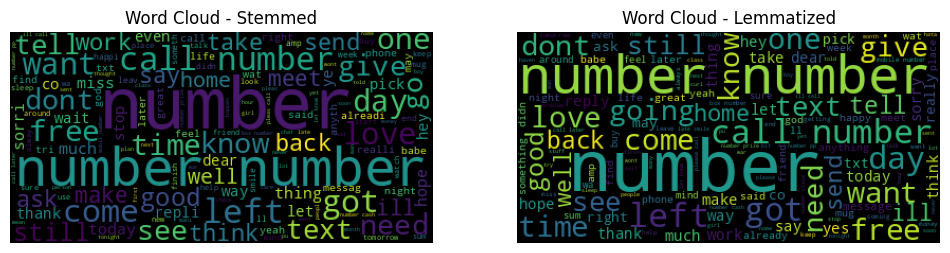

In [11]:
acc_df = pd.DataFrame({
    "Model": [m for m in results.keys()],
    "Stemmed": [results[m]["Stemmed Accuracy"] for m in results],
    "Lemmatized": [results[m]["Lemmatized Accuracy"] for m in results]
})

acc_df.plot(x="Model", kind="bar")
plt.title("Accuracy Comparison: Stemming vs Lemmatization")
plt.ylabel("Accuracy")
plt.show()

# Word Clouds for visualization
stem_text = " ".join(stemmed_corpus)
lemma_text = " ".join(lemmatized_corpus)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(WordCloud(max_words=200).generate(stem_text))
plt.title("Word Cloud - Stemmed")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(WordCloud(max_words=200).generate(lemma_text))
plt.title("Word Cloud - Lemmatized")
plt.axis("off")

plt.show()